# FAA Wildlife Strikes – Polars Exploration
This notebook inspects the downloaded FAA wildlife-strikes dataset (`data/wildlife-strikes/database.csv`) using Polars for fast tabular analytics.

In [1]:
from pathlib import Path
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
sns.set_theme(style="whitegrid")
DATA_DIR = Path.cwd().parent / "data" if Path.cwd().name == "notebooks" else Path.cwd() / "data"
csv_path = DATA_DIR / "wildlife-strikes" / "database.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"Expected dataset at {csv_path}. Run notebooks/download_wildlife.ipynb first.")
csv_path

PosixPath('/mnt/c/Users/Pritam/Documents/ISI_inference/data/wildlife-strikes/database.csv')

## Load Data
Read the CSV with Polars, keeping lazy mode available for efficient filtering.

In [2]:
lazy_df = pl.scan_csv(
    csv_path,
    ignore_errors=True,
    infer_schema_length=2000,
    schema_overrides={
        "Incident Year": pl.Int32,
        "Incident Month": pl.Int32,
        "Flight Phase": pl.Utf8,
        "Speed": pl.Float64,
        "Height": pl.Float64,
        "Distance": pl.Float64,
        "Aircraft Damage": pl.Float64,
        "State": pl.Utf8,
        "Species Name": pl.Utf8,
    },
    null_values=["", " ", "NA", "UNKNOWN"],
)
damage_lazy = lazy_df.with_columns(
    pl.col("Aircraft Damage")
    .cast(pl.Float64, strict=False)
    .fill_null(0)
    .clip(0, 1)
    .alias("damage_flag")
)
damage_lazy

### Damage target preparation
All downstream aggregations use `damage_flag`, a clipped binary indicator derived from `Aircraft Damage`, so damage rates stay consistent across features.

## Quick Peek
Materialize a small sample to inspect column names and data quality.

In [3]:
sample_df = lazy_df.head(5).collect()
sample_df

Record ID,Incident Year,Incident Month,Incident Day,Operator ID,Operator,Aircraft,Aircraft Type,Aircraft Make,Aircraft Model,Aircraft Mass,Engine Make,Engine Model,Engines,Engine Type,Engine1 Position,Engine2 Position,Engine3 Position,Engine4 Position,Airport ID,Airport,State,FAA Region,Warning Issued,Flight Phase,Visibility,Precipitation,Height,Speed,Distance,Species ID,Species Name,Species Quantity,Flight Impact,Fatalities,Injuries,Aircraft Damage,Radome Strike,Radome Damage,Windshield Strike,Windshield Damage,Nose Strike,Nose Damage,Engine1 Strike,Engine1 Damage,Engine2 Strike,Engine2 Damage,Engine3 Strike,Engine3 Damage,Engine4 Strike,Engine4 Damage,Engine Ingested,Propeller Strike,Propeller Damage,Wing or Rotor Strike,Wing or Rotor Damage,Fuselage Strike,Fuselage Damage,Landing Gear Strike,Landing Gear Damage,Tail Strike,Tail Damage,Lights Strike,Lights Damage,Other Strike,Other Damage
i64,i32,i32,i64,str,str,str,str,str,i64,i64,i64,str,i64,str,str,i64,str,i64,str,str,str,str,str,str,str,str,f64,f64,f64,str,str,str,str,str,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
127128,1990,1,1,"""DAL""","""DELTA AIR LINES""","""B-757-200""","""A""","""148""",26,4,34,"""40""",2,"""D""","""1""",1,null,null,"""KCVG""","""CINCINNATI/NORTHERN KENTUCKY I…","""KY""","""ASO""",null,"""CLIMB""",null,null,null,null,null,"""NE1""","""GULL""","""1""",null,null,null,1.0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0
129779,1990,1,1,"""HAL""","""HAWAIIAN AIR""","""DC-9""","""A""","""583""",90,4,34,"""10""",2,"""D""","""5""",5,null,null,"""PHLI""","""LIHUE ARPT""","""HI""","""AWP""",null,"""TAKEOFF RUN""",null,null,0.0,null,0.0,"""ZZ201""","""HOUSE SPARROW""","""1""",null,null,null,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
129780,1990,1,2,"""UNK""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""PHLI""","""LIHUE ARPT""","""HI""","""AWP""",null,null,null,null,null,null,0.0,"""R1101""","""BARN OWL""","""1""",null,null,null,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2258,1990,1,3,"""MIL""","""MILITARY""","""A-10A""","""A""","""345""",null,3,22,null,2,"""D""",null,null,null,null,"""KMYR""","""MYRTLE BEACH INTL""","""SC""","""ASO""",null,"""APPROACH""","""DAY""",null,200.0,138.0,null,"""UNKBM""","""UNKNOWN MEDIUM BIRD""","""1""",null,null,null,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2257,1990,1,3,"""MIL""","""MILITARY""","""F-16""","""A""","""561""",null,null,null,null,null,null,null,null,null,null,"""KJAX""","""JACKSONVILLE INTL""","""FL""","""ASO""",null,"""CLIMB""","""DAY""",null,100.0,200.0,null,"""ZX""","""FINCH""","""1""",null,null,null,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Schema Overview
Check column types to ensure downstream aggregations behave as expected.

In [4]:
schema = lazy_df.collect_schema()
schema

Schema([('Record ID', Int64),
        ('Incident Year', Int32),
        ('Incident Month', Int32),
        ('Incident Day', Int64),
        ('Operator ID', String),
        ('Operator', String),
        ('Aircraft', String),
        ('Aircraft Type', String),
        ('Aircraft Make', String),
        ('Aircraft Model', Int64),
        ('Aircraft Mass', Int64),
        ('Engine Make', Int64),
        ('Engine Model', String),
        ('Engines', Int64),
        ('Engine Type', String),
        ('Engine1 Position', String),
        ('Engine2 Position', Int64),
        ('Engine3 Position', String),
        ('Engine4 Position', Int64),
        ('Airport ID', String),
        ('Airport', String),
        ('State', String),
        ('FAA Region', String),
        ('Warning Issued', String),
        ('Flight Phase', String),
        ('Visibility', String),
        ('Precipitation', String),
        ('Height', Float64),
        ('Speed', Float64),
        ('Distance', Float64),
        ('Spec

## Categorical coverage
Leverage the schema to list every string column, inspect its usable observation count, and plot the category distribution for any chosen field.

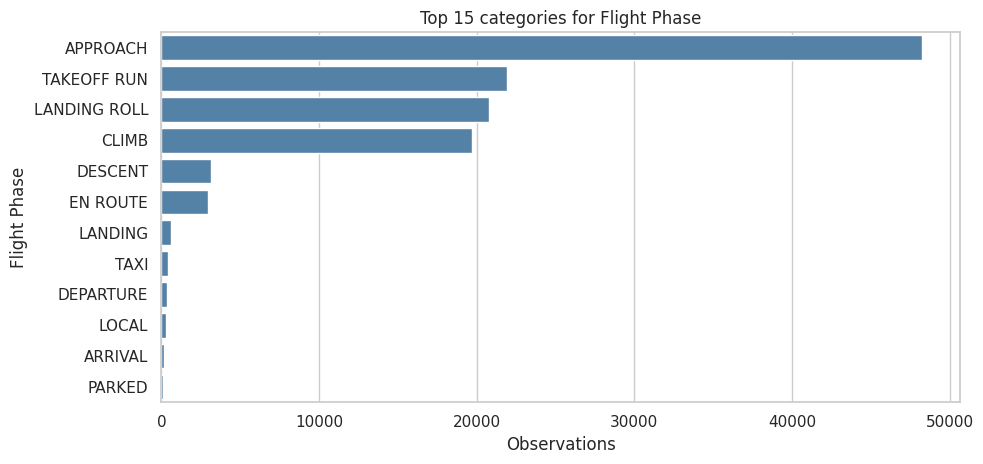

,Flight Phase,count
0,APPROACH,48275
1,TAKEOFF RUN,21953
2,LANDING ROLL,20762
3,CLIMB,19692
4,DESCENT,3174
5,EN ROUTE,2989
6,LANDING,626
7,TAXI,397
8,DEPARTURE,369
9,LOCAL,316


In [5]:
categorical_cols = [col for col, dtype in schema.items() if dtype == pl.Utf8]
categorical_overview = []
for col in categorical_cols:
    stats = (
        damage_lazy
        .select([
            pl.col(col).is_not_null().sum().alias("non_null"),
            pl.col(col).n_unique().alias("unique_values"),
        ])
        .collect()
        .to_dicts()[0]
    )
    categorical_overview.append(
        {
            "column": col,
            "non_null": int(stats["non_null"]),
            "unique_values": int(stats["unique_values"]),
        }
    )
categorical_overview_df = (
    pd.DataFrame(categorical_overview)
    .sort_values("non_null", ascending=False)
    .reset_index(drop=True)
)
categorical_overview_df
target_categorical = "Flight Phase"
if target_categorical not in categorical_overview_df["column"].values:
    target_categorical = categorical_overview_df.iloc[0]["column"]
top_n = 15
cat_counts_pd = pd.DataFrame(
    (
        damage_lazy
        .filter(pl.col(target_categorical).is_not_null())
        .group_by(target_categorical)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .head(top_n)
        .collect()
        .to_dicts()
    )
 )
plt.figure(figsize=(10, max(4, 0.4 * len(cat_counts_pd))))
sns.barplot(
    data=cat_counts_pd,
    x="count",
    y=target_categorical,
    color="steelblue",
)
plt.title(f"Top {top_n} categories for {target_categorical}")
plt.xlabel("Observations")
plt.ylabel(target_categorical)
plt.tight_layout()
plt.show()
cat_counts_pd

## Summary Statistics
Compute basic stats for numeric columns (e.g., cost, altitude).

In [6]:
numeric_cols = [c for c, dt in schema.items() if dt.is_numeric()]
summary = lazy_df.select([pl.col(col).mean().alias(f"{col}_mean") for col in numeric_cols]).collect()
summary

Record ID_mean,Incident Year_mean,Incident Month_mean,Incident Day_mean,Aircraft Model_mean,Aircraft Mass_mean,Engine Make_mean,Engines_mean,Engine2 Position_mean,Engine4 Position_mean,Height_mean,Speed_mean,Distance_mean,Injuries_mean,Aircraft Damage_mean,Radome Strike_mean,Radome Damage_mean,Windshield Strike_mean,Windshield Damage_mean,Nose Strike_mean,Nose Damage_mean,Engine1 Strike_mean,Engine1 Damage_mean,Engine2 Strike_mean,Engine2 Damage_mean,Engine3 Strike_mean,Engine3 Damage_mean,Engine4 Strike_mean,Engine4 Damage_mean,Engine Ingested_mean,Propeller Strike_mean,Propeller Damage_mean,Wing or Rotor Strike_mean,Wing or Rotor Damage_mean,Fuselage Strike_mean,Fuselage Damage_mean,Landing Gear Strike_mean,Landing Gear Damage_mean,Tail Strike_mean,Tail Damage_mean,Lights Strike_mean,Lights Damage_mean,Other Strike_mean,Other Damage_mean
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
241204.036915,2006.036392,7.17184,15.712264,24.792463,3.510611,21.306958,2.057656,2.91857,2.058538,831.032283,141.925622,0.703738,1.746725,0.085977,0.107757,0.00915,0.138934,0.005956,0.122369,0.006577,0.055605,0.014445,0.045168,0.011619,0.003182,0.000971,0.001918,0.000425,0.05518,0.020086,0.003326,0.119159,0.024009,0.102703,0.004733,0.046242,0.005813,0.011235,0.004176,0.005962,0.004216,0.090727,0.008989


## Species Impact
Find which species appear most frequently in the strike reports.

/tmp/ipykernel_255673/241753505.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


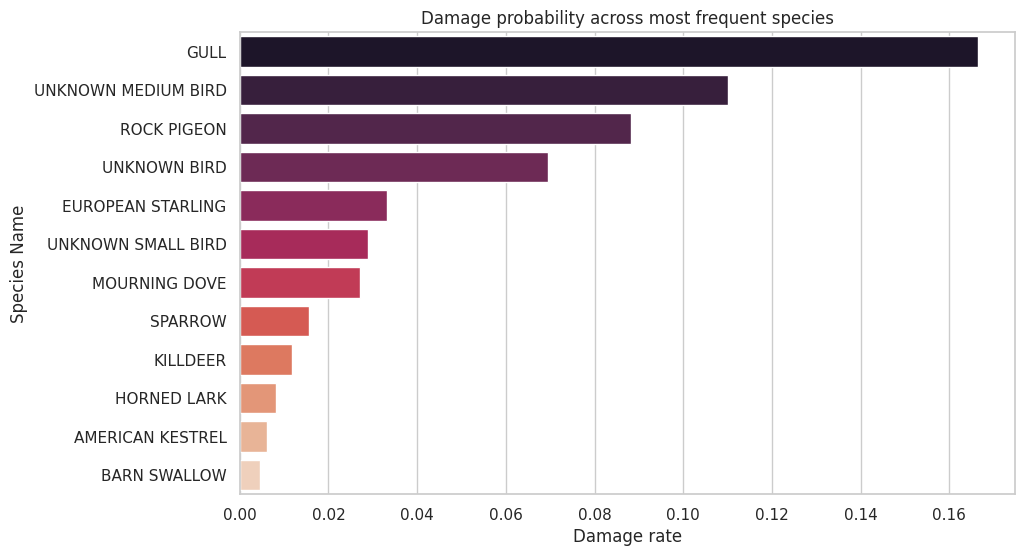

,Species Name,strike_count,damage_rate
0,UNKNOWN MEDIUM BIRD,38531,0.110119
1,UNKNOWN SMALL BIRD,32981,0.028865
2,MOURNING DOVE,7653,0.027179
3,GULL,6580,0.166413
4,UNKNOWN BIRD,6400,0.069531
5,KILLDEER,4562,0.011837
6,AMERICAN KESTREL,4476,0.006256
7,BARN SWALLOW,4215,0.004508
8,HORNED LARK,3952,0.008097
9,EUROPEAN STARLING,3915,0.033206


In [7]:
species_counts = (
    damage_lazy
    .filter(pl.col("Species Name").is_not_null())
    .group_by("Species Name")
    .agg(
        pl.len().alias("strike_count"),
        pl.col("damage_flag").mean().alias("damage_rate"),
    )
    .sort("strike_count", descending=True)
    .head(12)
    .collect()
 )
species_counts_pd = pd.DataFrame(species_counts.to_dicts())
plt.figure(figsize=(10, 6))
sns.barplot(
    data=species_counts_pd.sort_values("damage_rate", ascending=False),
    x="damage_rate",
    y="Species Name",
    palette="rocket",
)
plt.xlabel("Damage rate")
plt.ylabel("Species Name")
plt.title("Damage probability across most frequent species")
plt.show()
species_counts_pd

## Damage Rate by Phase of Flight
Approximate which flight phases most often result in aircraft damage (any status other than `NONE`).

/tmp/ipykernel_255673/1139329235.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


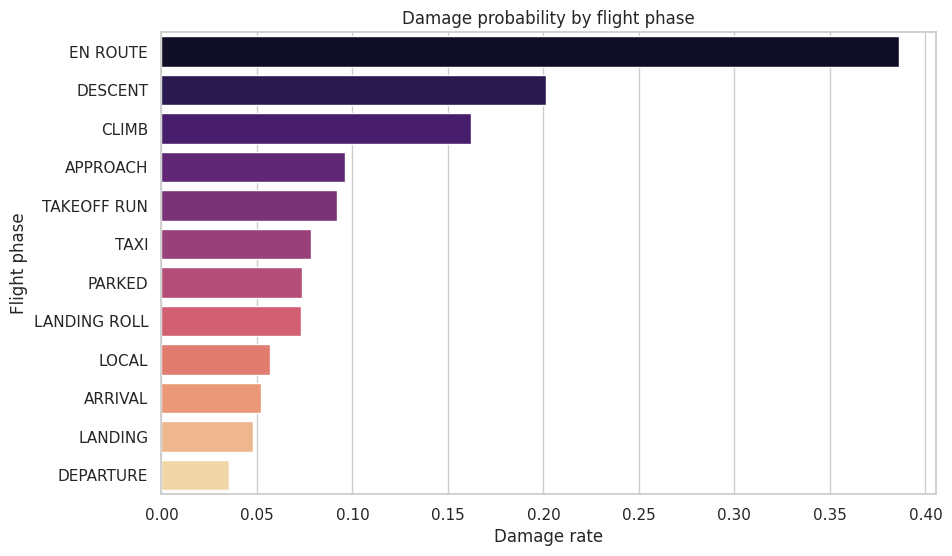

,Flight Phase,event_count,damage_rate
0,EN ROUTE,2989,0.386417
1,DESCENT,3174,0.201323
2,CLIMB,19692,0.162350
3,APPROACH,48275,0.096075
4,TAKEOFF RUN,21953,0.091878
5,TAXI,397,0.078086
6,PARKED,95,0.073684
7,LANDING ROLL,20762,0.073307
8,LOCAL,316,0.056962
9,ARRIVAL,154,0.051948


In [8]:
damage_by_phase = (
    damage_lazy
    .filter(pl.col("Flight Phase").is_not_null())
    .group_by("Flight Phase")
    .agg(
        pl.len().alias("event_count"),
        pl.col("damage_flag").mean().alias("damage_rate"),
    )
    .sort("damage_rate", descending=True)
    .collect()
 )
damage_phase_pd = pd.DataFrame(damage_by_phase.to_dicts())
plt.figure(figsize=(10, 6))
sns.barplot(
    data=damage_phase_pd,
    x="damage_rate",
    y="Flight Phase",
    palette="magma",
)
plt.xlabel("Damage rate")
plt.ylabel("Flight phase")
plt.title("Damage probability by flight phase")
plt.show()
damage_phase_pd

## Temporal Trend of Wildlife Strikes
Plot yearly strike counts to observe macro trends in reporting volume.

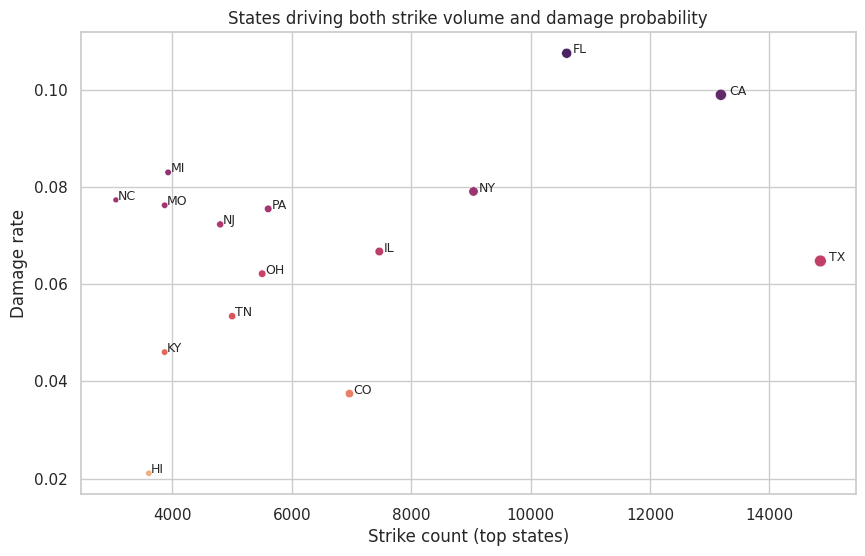

,State,strike_count,damage_rate
0,TX,14854,0.064764
1,CA,13187,0.098961
2,FL,10604,0.107507
3,NY,9043,0.079067
4,IL,7465,0.066711
5,CO,6965,0.037473
6,PA,5604,0.075482
7,OH,5503,0.062148
8,TN,5000,0.053400
9,NJ,4800,0.072292


In [9]:
state_damage = (
    damage_lazy
    .filter(pl.col("State").is_not_null())
    .group_by("State")
    .agg(
        pl.len().alias("strike_count"),
        pl.col("damage_flag").mean().alias("damage_rate"),
    )
    .sort("strike_count", descending=True)
    .head(15)
    .collect()
 )
state_damage_pd = pd.DataFrame(state_damage.to_dicts())
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=state_damage_pd,
    x="strike_count",
    y="damage_rate",
    size="strike_count",
    hue="damage_rate",
    palette="flare",
    legend=False
)
plt.xlabel("Strike count (top states)")
plt.ylabel("Damage rate")
plt.title("States driving both strike volume and damage probability")
for _, row in state_damage_pd.iterrows():
    plt.text(
        row["strike_count"] * 1.01,
        row["damage_rate"],
        row["State"],
        fontsize=9,
    )
plt.show()
state_damage_pd

## Top States by Reported Strikes
Highlight the busiest 15 states to identify regional risk.

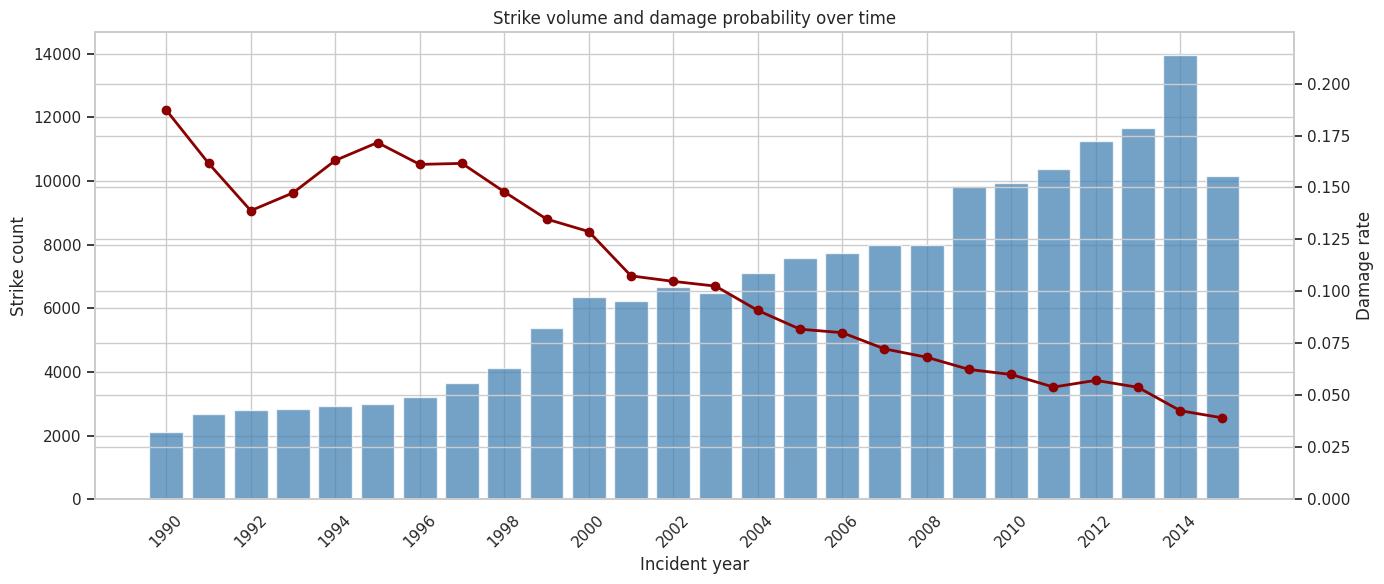

,Incident Year,strike_count,damage_rate
0,1990,2099,0.187232
1,1991,2672,0.161677
2,1992,2816,0.138849
3,1993,2849,0.147420
4,1994,2938,0.163036
5,1995,2989,0.171629
6,1996,3215,0.161120
7,1997,3651,0.161600
8,1998,4131,0.147906
9,1999,5385,0.134819


In [14]:
year_damage = (
    damage_lazy
    .filter(pl.col("Incident Year").is_not_null())
    .group_by("Incident Year")
    .agg(
        pl.len().alias("strike_count"),
        pl.col("damage_flag").mean().alias("damage_rate"),
    )
    .sort("Incident Year")
    .collect()
 )
year_damage_pd = pd.DataFrame(year_damage.to_dicts())
years = year_damage_pd["Incident Year"].astype(int)
strike_counts = year_damage_pd["strike_count"]
damage_rates = year_damage_pd["damage_rate"]
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(years, strike_counts, color="steelblue", alpha=0.75)
ax1.set_ylabel("Strike count")
ax1.set_xlabel("Incident year")
ax1.set_xticks(years[::2])
ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
ax2.plot(years, damage_rates, color="darkred", marker="o", linewidth=2)
ax2.set_ylabel("Damage rate")
ax2.set_ylim(0, damage_rates.max() * 1.2)
plt.title("Strike volume and damage probability over time")
plt.tight_layout()
plt.show()
year_damage_pd

## Damage relationship with numeric covariates
Bucket continuous features to expose how strike severity responds to operational context, then quantify the direct association with the binary damage flag.

/tmp/ipykernel_255673/2543891427.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  feature_df.groupby("bin")["damage_flag"]
/tmp/ipykernel_255673/2543891427.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  feature_df.groupby("bin")["damage_flag"]


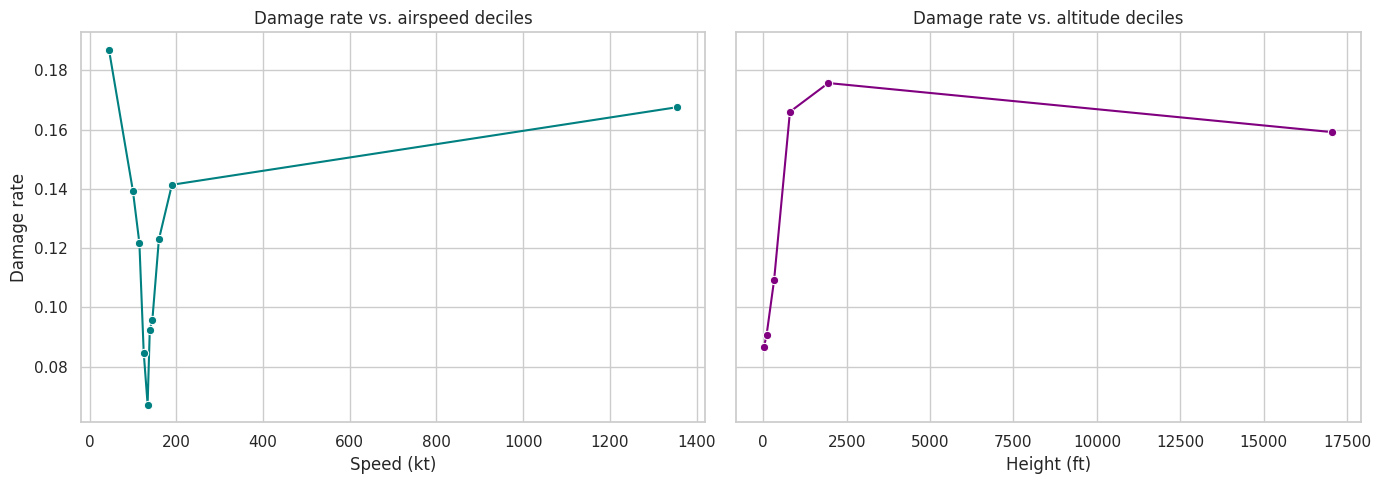

In [15]:
numeric_subset = pd.DataFrame((
    damage_lazy
    .select([
        pl.col("Speed").alias("speed"),
        pl.col("Height").alias("height"),
        pl.col("Distance").alias("distance"),
        pl.col("Species Quantity").alias("species_quantity"),
        pl.col("damage_flag"),
    ])
    .collect()
    .to_dicts()
 ))
def summarize_bins(df: pd.DataFrame, feature: str, q: int = 10) -> pd.DataFrame:
    feature_df = df.dropna(subset=[feature]).copy()
    if feature_df.empty:
        return pd.DataFrame(columns=[feature, "bin_mid", "damage_rate", "count"])
    feature_df["bin"] = pd.qcut(feature_df[feature], q=q, duplicates="drop")
    summary = (
        feature_df.groupby("bin")["damage_flag"]
        .agg(["mean", "count"])
        .reset_index()
        .rename(columns={"mean": "damage_rate"})
    )
    summary["bin_mid"] = summary["bin"].apply(
        lambda interval: interval.mid if pd.notnull(interval) else np.nan
    )
    summary[feature] = summary["bin"].astype(str)
    return summary
speed_summary = summarize_bins(numeric_subset, "speed")
height_summary = summarize_bins(numeric_subset, "height")
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.lineplot(
    data=speed_summary,
    x="bin_mid",
    y="damage_rate",
    marker="o",
    ax=axes[0],
    color="teal",
)
axes[0].set_title("Damage rate vs. airspeed deciles")
axes[0].set_xlabel("Speed (kt)")
axes[0].set_ylabel("Damage rate")
sns.lineplot(
    data=height_summary,
    x="bin_mid",
    y="damage_rate",
    marker="o",
    ax=axes[1],
    color="purple",
)
axes[1].set_title("Damage rate vs. altitude deciles")
axes[1].set_xlabel("Height (ft)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

/mnt/c/Users/Pritam/Documents/ISI_inference/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:5534: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)
/tmp/ipykernel_255673/3232216925.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


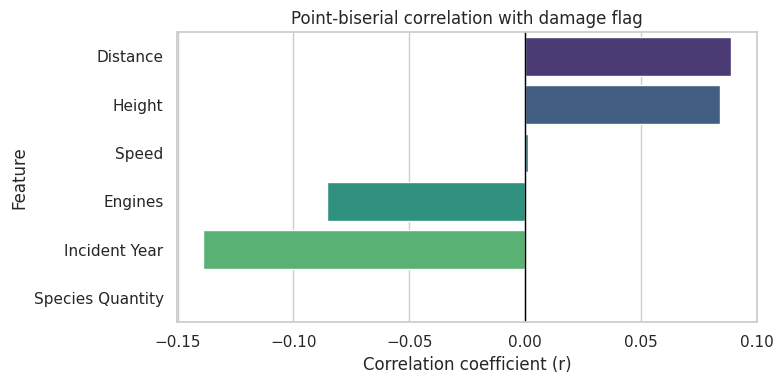

,feature,point_biserial_r,p_value,n
3,Distance,0.088640,4.592857e-173,99713
2,Height,0.084100,4.708266e-162,103677
1,Speed,0.001303,7.278836e-01,71258
5,Engines,-0.085495,3.626348e-205,127342
0,Incident Year,-0.138950,0.000000e+00,174104
4,Species Quantity,NaN,NaN,146563


In [16]:
numeric_cols = [
    "Incident Year",
    "Speed",
    "Height",
    "Distance",
    "Species Quantity",
    "Engines",
 ]
corr_rows = []
numeric_corr_df = pd.DataFrame((
    damage_lazy
    .select([pl.col(col) for col in numeric_cols] + [pl.col("damage_flag")])
    .collect()
    .to_dicts()
))
for col in numeric_cols:
    # ensure numeric dtype for correlation
    numeric_corr_df[col] = pd.to_numeric(numeric_corr_df[col], errors="coerce")
for col in numeric_cols:
    subset = numeric_corr_df[[col, "damage_flag"]].dropna()
    if subset.empty:
        continue
    r, p_value = pointbiserialr(subset["damage_flag"], subset[col])
    corr_rows.append({
        "feature": col,
        "point_biserial_r": r,
        "p_value": p_value,
        "n": len(subset),
    })
corr_df = pd.DataFrame(corr_rows).sort_values("point_biserial_r", ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(
    data=corr_df,
    x="point_biserial_r",
    y="feature",
    palette="viridis",
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Point-biserial correlation with damage flag")
plt.xlabel("Correlation coefficient (r)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
corr_df